# 🛒 Customer Segmentation using RFM Analysis + K-Means Clustering

**Dataset:** Online Retail Dataset (UCI / Kaggle)  
**Tech Stack:** pandas, numpy, scikit-learn, matplotlib, seaborn  

---
### 📌 Pipeline:
`Data Loading → Cleaning → RFM Engineering → Normalization → K-Means → Visualization → Insights`

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2: Load Dataset
> 📥 Download from: https://www.kaggle.com/datasets/vijayuv/onlineretail  
> Save as **`OnlineRetail.csv`** in the same folder as this notebook.

In [4]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

print(f'Shape: {df.shape}')
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## Step 3: Data Cleaning

In [7]:
# Drop rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# Remove cancelled orders (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero Quantity/UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate TotalPrice per row
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f'✅ Clean shape: {df.shape}')
df.head()

✅ Clean shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Step 4: RFM Feature Engineering

| Feature | Meaning |
|---|---|
| **Recency** | How recently did the customer buy? (in days) |
| **Frequency** | How many unique orders did they place? |
| **Monetary** | How much total money did they spend? |

In [8]:
# Reference date = 1 day after last transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date}')

# Calculate RFM
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f'\nRFM shape: {rfm.shape}')
rfm.head(10)

Snapshot date: 2011-12-10 12:50:00

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [9]:
# Statistical summary of RFM
rfm.describe().round(2)

,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


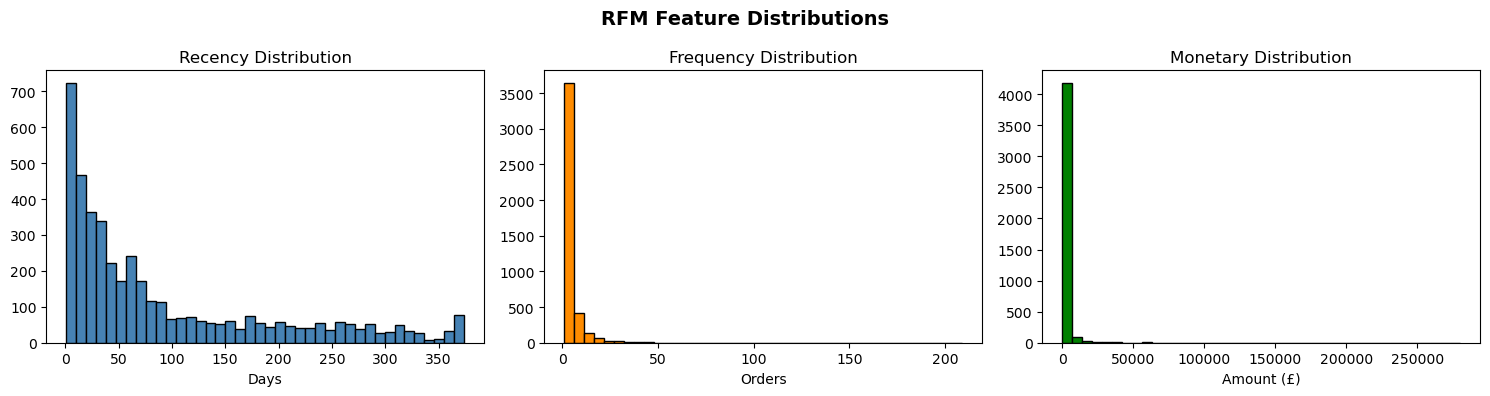

In [10]:
# RFM Distribution Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'], bins=40, color='darkorange', edgecolor='black')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Orders')

axes[2].hist(rfm['Monetary'], bins=40, color='green', edgecolor='black')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Amount (£)')

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Normalize RFM Values

In [11]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print('✅ Normalization done!')
print(f'Mean after scaling: {rfm_scaled.mean(axis=0).round(4)}')
print(f'Std after scaling:  {rfm_scaled.std(axis=0).round(4)}')

✅ Normalization done!
Mean after scaling: [0. 0. 0.]
Std after scaling:  [1. 1. 1.]


## Step 6: Elbow Method — Find Optimal K

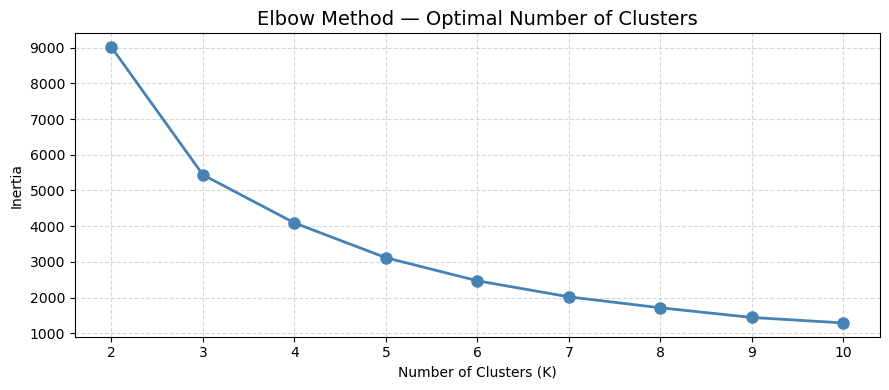

👉 Look for the "elbow" point where inertia drop slows — that is the best K.


In [13]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('👉 Look for the "elbow" point where inertia drop slows — that is the best K.')

## Step 7: K-Means Clustering (K=4)

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Silhouette Score
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f'✅ K-Means done!')
print(f'Silhouette Score: {score:.4f}  (closer to 1.0 = better separation)')

rfm.head()

✅ K-Means done!
Silhouette Score: 0.6162  (closer to 1.0 = better separation)


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


## Step 8: Cluster Analysis

In [15]:
cluster_summary = rfm.groupby('Cluster').agg(
    Customer_Count = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean')
).round(2)

print('📊 Cluster Summary:')
cluster_summary

📊 Cluster Summary:


,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1359.05
1,1067,248.08,1.55,480.62
2,13,7.38,82.54,127338.31
3,204,15.50,22.33,12709.09


## Step 9: Label Segments

In [16]:
segment_map = {}

for cluster, row in cluster_summary.iterrows():
    r = row['Avg_Recency']
    f = row['Avg_Frequency']
    m = row['Avg_Monetary']

    if r < 30 and f > 5 and m > 1000:
        label = '🏆 Champions'
    elif r < 60 and f > 3:
        label = '💛 Loyal Customers'
    elif r > 150:
        label = '❌ Lost Customers'
    else:
        label = '⚠️ At Risk'

    segment_map[cluster] = label

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print('🏷️ Segment Distribution:')
print(rfm['Segment'].value_counts())
rfm.head()

🏷️ Segment Distribution:
Segment
💛 Loyal Customers    3054
❌ Lost Customers     1067
🏆 Champions           217
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,🏆 Champions
1,12347.0,2,7,4310.00,0,💛 Loyal Customers
2,12348.0,75,4,1797.24,0,💛 Loyal Customers
3,12349.0,19,1,1757.55,0,💛 Loyal Customers
4,12350.0,310,1,334.40,1,❌ Lost Customers


## Step 10: Visualizations

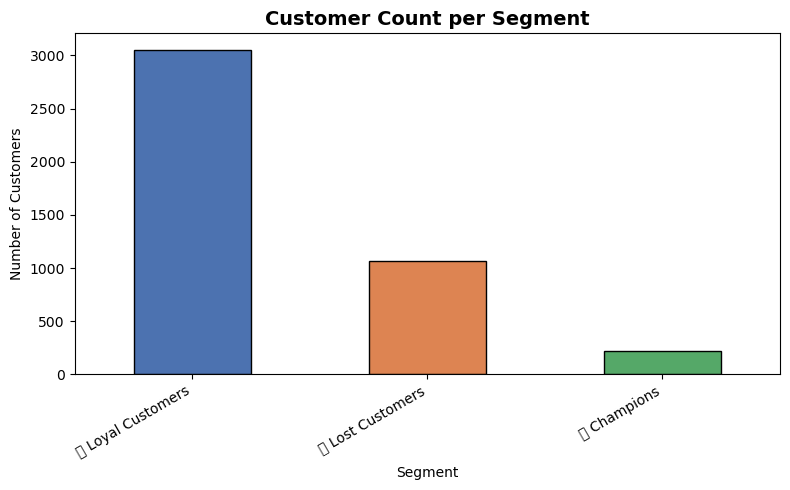

In [17]:
# Plot 1: Customer Count per Segment
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(8, 5))
seg_counts = rfm['Segment'].value_counts()
seg_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Customer Count per Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

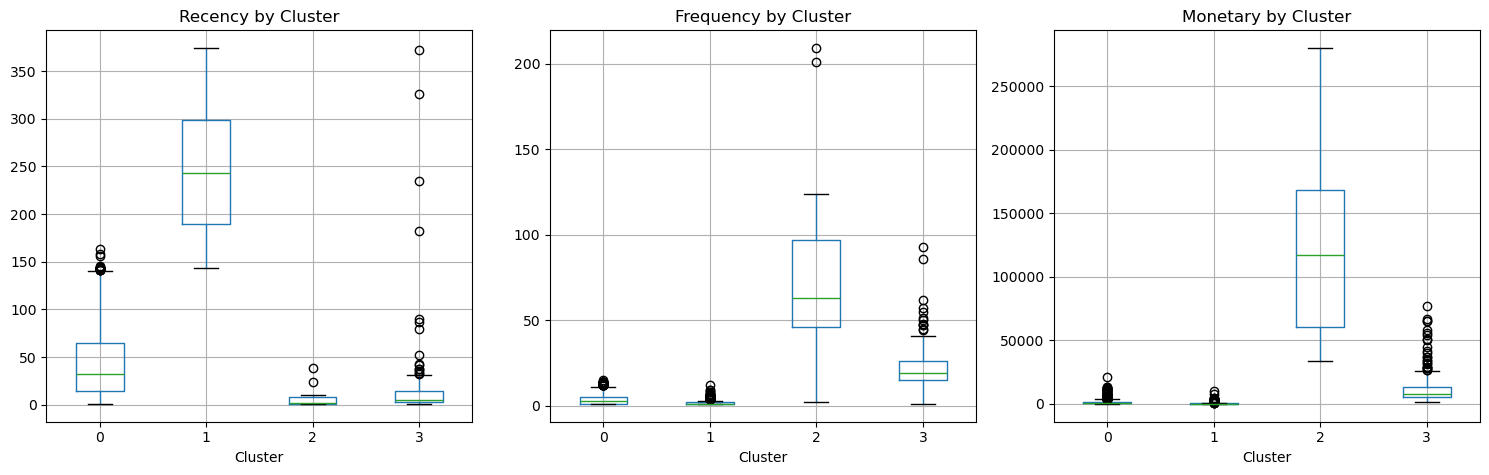

In [18]:
# Plot 2: RFM Box Plots by Cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    rfm.boxplot(column=col, by='Cluster', ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')

plt.suptitle('')
plt.tight_layout()
plt.show()

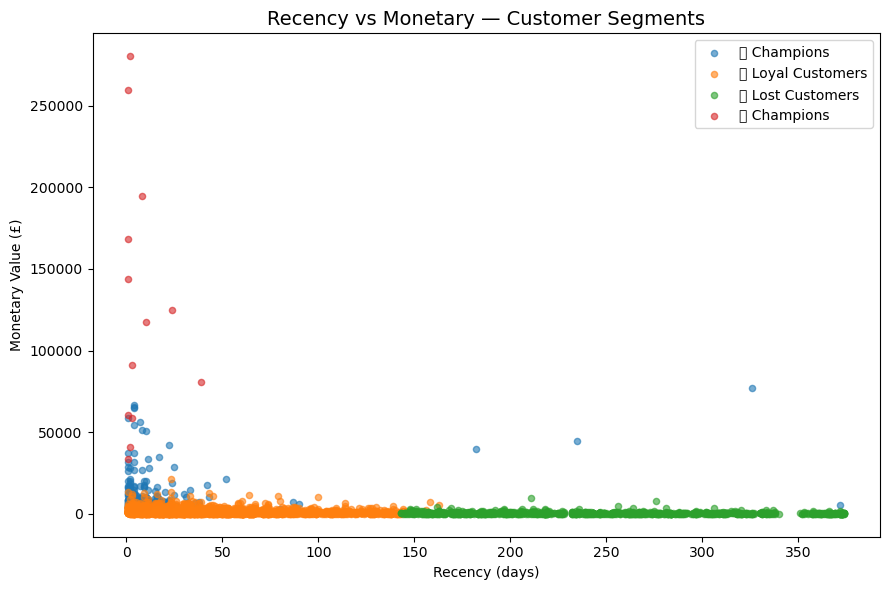

In [19]:
# Plot 3: Scatter — Recency vs Monetary
plt.figure(figsize=(9, 6))

for c in rfm['Cluster'].unique():
    subset = rfm[rfm['Cluster'] == c]
    plt.scatter(subset['Recency'], subset['Monetary'],
                label=segment_map[c], alpha=0.6, s=20)

plt.title('Recency vs Monetary — Customer Segments', fontsize=14)
plt.xlabel('Recency (days)')
plt.ylabel('Monetary Value (£)')
plt.legend()
plt.tight_layout()
plt.show()

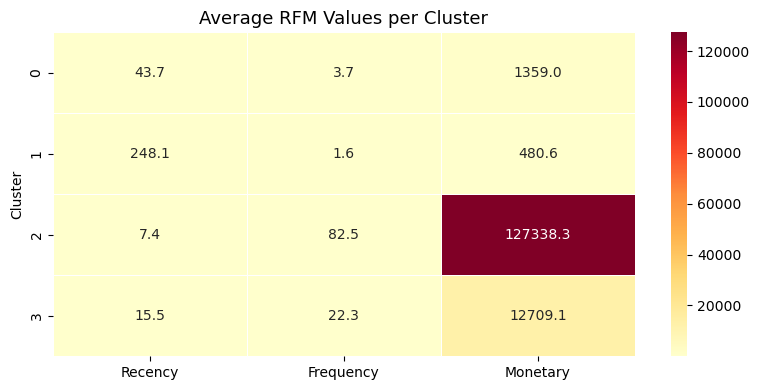

In [20]:
# Plot 4: Heatmap — Avg RFM per Cluster
heatmap_data = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average RFM Values per Cluster', fontsize=13)
plt.tight_layout()
plt.show()

## Step 11: Save Results

In [ ]:
rfm.to_csv('rfm_segments.csv', index=False)
print('📁 Results saved to rfm_segments.csv')
print('\n🎉 Project Complete!')
rfm.sample(10)

---
## 📌 Summary

| Segment | Description | Strategy |
|---|---|---|
| 🏆 Champions | Buy often, spend most, bought recently | Reward them, ask for reviews |
| 💛 Loyal Customers | Buy regularly, decent spend | Upsell, loyalty programs |
| ⚠️ At Risk | Were good customers, now slipping | Send win-back campaigns |
| ❌ Lost Customers | Haven't bought in very long time | Aggressive discounts or let go |